In [1]:
import pandas as pd
import os

print("Diretório atual:")
print(os.getcwd())

Diretório atual:
C:\Users\Amanda Cristina\Desktop\Mestrado Ufla\Segundo Semestre\PCC557 - Tópicos em IA


In [2]:
import os

pasta = r"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset"

print(os.listdir(pasta))

['Train_Test_IoT_Fridge.csv', 'Train_Test_IoT_Garage_Door.csv', 'Train_Test_IoT_GPS_Tracker.csv', 'Train_Test_IoT_Modbus.csv', 'Train_Test_IoT_Motion_Light.csv', 'Train_Test_IoT_Thermostat.csv', 'Train_Test_IoT_Weather.csv']


In [3]:
import pandas as pd

arquivo = r"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset\Train_Test_IoT_Weather.csv"

df = pd.read_csv(arquivo)

print("Dimensões:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

Dimensões: (39260, 7)

Colunas:
['date', 'time', 'temperature', 'pressure', 'humidity', 'label', 'type']


In [4]:
print("Valores únicos de label:")
print(df["label"].unique())

print("\nValores únicos de type:")
print(df["type"].unique())

Valores únicos de label:
[1 0]

Valores únicos de type:
<StringArray>
[      'ddos',   'backdoor',  'injection',     'normal',   'password',
 'ransomware',   'scanning',        'xss']
Length: 8, dtype: str


In [5]:
print(df["label"].value_counts())

print("\nPercentual:")
print(df["label"].value_counts(normalize=True)*100)

label
1    24260
0    15000
Name: count, dtype: int64

Percentual:
label
1    61.793174
0    38.206826
Name: proportion, dtype: float64


In [6]:
print(pd.crosstab(df["label"], df["type"]))

type   backdoor  ddos  injection  normal  password  ransomware  scanning  xss
label                                                                        
0             0     0          0   15000         0           0         0    0
1          5000  5000       5000       0      5000        2865       529  866


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Variáveis de entrada
X = df[["temperature", "pressure", "humidity"]]

# Variável alvo
y = df["label"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Modelo
modelo = LogisticRegression(max_iter=1000)

# Treinamento
modelo.fit(X_train, y_train)

# Previsões
y_pred = modelo.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nRelatório:")
print(classification_report(y_test, y_pred))

Accuracy: 0.609271523178808

Relatório:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3000
           1       0.61      0.99      0.76      4852

    accuracy                           0.61      7852
   macro avg       0.31      0.49      0.38      7852
weighted avg       0.38      0.61      0.47      7852



In [8]:
for arquivo in [
    "Train_Test_IoT_Modbus.csv",
    "Train_Test_IoT_GPS_Tracker.csv",
    "Train_Test_IoT_Garage_Door.csv"
]:
    
    caminho = rf"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset\{arquivo}"
    
    df_temp = pd.read_csv(caminho)
    
    print("\n")
    print(arquivo)
    print(df_temp.shape)
    print(df_temp.columns.tolist())




Train_Test_IoT_Modbus.csv
(31106, 8)
['date', 'time', 'FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'label', 'type']


Train_Test_IoT_GPS_Tracker.csv
(38960, 6)
['date', 'time', 'latitude', 'longitude', 'label', 'type']


Train_Test_IoT_Garage_Door.csv
(39587, 6)
['date', 'time', 'door_state', 'sphone_signal', 'label', 'type']


In [9]:
arquivo = r"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset\Train_Test_IoT_Modbus.csv"

df_modbus = pd.read_csv(arquivo)

print(df_modbus.head())

print("\n")
print(df_modbus["label"].value_counts())

print("\n")
print(pd.crosstab(df_modbus["label"], df_modbus["type"]))

        date        time  FC1_Read_Input_Register  FC2_Read_Discrete_Value  \
0  25-Apr-19   09:14:00                     49389                    52921   
1  25-Apr-19   09:14:00                     49389                    52921   
2  25-Apr-19   09:14:01                     49389                    52921   
3  25-Apr-19   09:14:02                     49389                    52921   
4  25-Apr-19   09:14:04                     40665                    44748   

   FC3_Read_Holding_Register  FC4_Read_Coil  label       type  
0                      25770          13625      1  injection  
1                      25770          13625      1  injection  
2                      25770          13625      1  injection  
3                      25770          13625      1  injection  
4                      21098          35371      1  injection  


label
1    16106
0    15000
Name: count, dtype: int64


type   backdoor  injection  normal  password  scanning  xss
label                        

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

X = df_modbus[
    [
        "FC1_Read_Input_Register",
        "FC2_Read_Discrete_Value",
        "FC3_Read_Holding_Register",
        "FC4_Read_Coil"
    ]
]

y = df_modbus["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.514143362262938


              precision    recall  f1-score   support

           0       0.48      0.10      0.16      3000
           1       0.52      0.90      0.66      3222

    accuracy                           0.51      6222
   macro avg       0.50      0.50      0.41      6222
weighted avg       0.50      0.51      0.42      6222



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

X = df_modbus[
    [
        "FC1_Read_Input_Register",
        "FC2_Read_Discrete_Value",
        "FC3_Read_Holding_Register",
        "FC4_Read_Coil"
    ]
]

y = df_modbus["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.514143362262938

              precision    recall  f1-score   support

           0       0.48      0.10      0.16      3000
           1       0.52      0.90      0.66      3222

    accuracy                           0.51      6222
   macro avg       0.50      0.50      0.41      6222
weighted avg       0.50      0.51      0.42      6222



In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9845708775313404

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3000
           1       0.99      0.98      0.98      3222

    accuracy                           0.98      6222
   macro avg       0.98      0.98      0.98      6222
weighted avg       0.98      0.98      0.98      6222



In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32,16),
        max_iter=300,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print()
print(classification_report(y_test, y_pred_mlp))

Accuracy: 0.5765027322404371

              precision    recall  f1-score   support

           0       0.58      0.46      0.51      3000
           1       0.58      0.69      0.63      3222

    accuracy                           0.58      6222
   macro avg       0.58      0.57      0.57      6222
weighted avg       0.58      0.58      0.57      6222



C:\Users\Amanda Cristina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
import pandas as pd

df = pd.read_csv(
    r"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset\Train_Test_IoT_Garage_Door.csv"
)

print(df.head())
print()
print(df.shape)
print()
print(df.columns.tolist())

        date        time door_state sphone_signal  label  type
0  25-Apr-19   14:42:33      closed             0      1  ddos
1  25-Apr-19   14:42:38      closed             0      1  ddos
2  25-Apr-19   14:42:43      closed             0      1  ddos
3  25-Apr-19   14:42:48      closed             0      1  ddos
4  25-Apr-19   14:42:58      closed             0      1  ddos

(39587, 6)

['date', 'time', 'door_state', 'sphone_signal', 'label', 'type']


In [15]:
print(df["label"].value_counts())
print()

print(pd.crosstab(df["label"], df["type"]))

label
1    24587
0    15000
Name: count, dtype: int64

type   backdoor  ddos  injection  normal  password  ransomware  scanning   xss
label                                                                         
0             0     0          0   15000         0           0         0     0
1          5000  5000       5000       0      5000        2902       529  1156


In [16]:
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()

df2["door_state"] = LabelEncoder().fit_transform(df2["door_state"])
df2["sphone_signal"] = LabelEncoder().fit_transform(df2["sphone_signal"])

print(df2.head())

        date        time  door_state  sphone_signal  label  type
0  25-Apr-19   14:42:33            0              0      1  ddos
1  25-Apr-19   14:42:38            0              0      1  ddos
2  25-Apr-19   14:42:43            0              0      1  ddos
3  25-Apr-19   14:42:48            0              0      1  ddos
4  25-Apr-19   14:42:58            0              0      1  ddos


In [17]:
from sklearn.model_selection import train_test_split

X = df2[["door_state", "sphone_signal"]]

y = df2["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      4918

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      4918

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(16,),
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print()
print(classification_report(y_test, y_pred_mlp))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      4918

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



In [21]:
print(df2.groupby("label")["door_state"].value_counts())
print()

print(df2.groupby("label")["sphone_signal"].value_counts())

label  door_state
0      0             13478
       1              1522
1      0             22097
       1              2490
Name: count, dtype: int64

label  sphone_signal
0      2                13478
       3                 1522
1      0                22097
       1                 2490
Name: count, dtype: int64


In [22]:
label  door_state
0      0             13478
       1              1522
1      0             22097
       1              2490
Name: count, dtype: int64

label  sphone_signal
0      2                13478
       3                 1522
1      0                22097
       1                 2490
Name: count, dtype: int64

SyntaxError: invalid syntax (1746084081.py, line 1)

In [23]:
df = pd.read_csv(
    r"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset\Train_Test_IoT_GPS_Tracker.csv"
)

print(df.head())
print()
print(df.shape)
print()
print(df.columns.tolist())
print()
print(df["label"].value_counts())

        date        time    latitude   longitude  label  type
0  25-Apr-19   18:31:39   116.521704  132.162504      1  ddos
1  25-Apr-19   18:31:41   121.742933  135.072500      1  ddos
2  25-Apr-19   18:31:46   121.795929  135.110198      1  ddos
3  25-Apr-19   18:31:49   116.611216  132.224555      1  ddos
4  25-Apr-19   18:31:51   121.841526  135.151362      1  ddos

(38960, 6)

['date', 'time', 'latitude', 'longitude', 'label', 'type']

label
1    23960
0    15000
Name: count, dtype: int64


In [24]:
print(pd.crosstab(df["label"], df["type"]))

type   backdoor  ddos  injection  normal  password  ransomware  scanning  xss
label                                                                        
0             0     0          0   15000         0           0         0    0
1          5000  5000       5000       0      5000        2833       550  577


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      4918

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      4918

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(16,),
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print()
print(classification_report(y_test, y_pred_mlp))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       1.00      1.00      1.00      4918

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



In [28]:
print(df.groupby("label")["latitude"].describe())

print()

print(df.groupby("label")["longitude"].describe())

         count       mean        std  min        25%        50%         75%  \
label                                                                         
0      15000.0  18.577057  34.952463  0.0   0.611293   1.644128    4.031503   
1      23960.0  78.647963  84.124796  0.0  28.961727  62.853176  101.674759   

              max  
label              
0      114.583173  
1      549.381916  

         count       mean        std   min        25%        50%         75%  \
label                                                                          
0      15000.0  28.613425  35.000365  10.0  10.642455  11.658494   13.957012   
1      23960.0  89.161174  85.059316  10.0  39.382448  72.468818  111.476120   

              max  
label              
0      121.479841  
1      555.133643  


In [29]:
df = pd.read_csv(
    r"Base de dados\Train_Test_datasets\Train_Test_IoT_dataset\Train_Test_IoT_Weather.csv"
)

print(df.head())
print()
print(df.shape)
print()
print(df.columns.tolist())

        date      time  temperature  pressure   humidity  label  type
0  25-Apr-19  17:33:16    40.881866 -0.101806  38.363631      1  ddos
1  25-Apr-19  17:33:16    44.913806  2.661616  46.141423      1  ddos
2  25-Apr-19  17:33:16    38.295822 -2.438871  50.850643      1  ddos
3  25-Apr-19  17:33:21    41.306586 -0.101806  38.363631      1  ddos
4  25-Apr-19  17:33:21    44.903178  3.080849  46.141423      1  ddos

(39260, 7)

['date', 'time', 'temperature', 'pressure', 'humidity', 'label', 'type']


In [30]:
print(df["label"].value_counts())

print()

print(pd.crosstab(df["label"], df["type"]))

label
1    24260
0    15000
Name: count, dtype: int64

type   backdoor  ddos  injection  normal  password  ransomware  scanning  xss
label                                                                        
0             0     0          0   15000         0           0         0    0
1          5000  5000       5000       0      5000        2865       529  866


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Entradas e alvo
X = df[["temperature", "pressure", "humidity"]]
y = df["label"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# 3. MLP
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(16,),
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("===== MLP =====")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

===== Logistic Regression =====
Accuracy: 0.609271523178808
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3000
           1       0.61      0.99      0.76      4852

    accuracy                           0.61      7852
   macro avg       0.31      0.49      0.38      7852
weighted avg       0.38      0.61      0.47      7852

===== Random Forest =====
Accuracy: 0.9847172694854814
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3000
           1       0.99      0.99      0.99      4852

    accuracy                           0.98      7852
   macro avg       0.98      0.98      0.98      7852
weighted avg       0.98      0.98      0.98      7852

===== MLP =====
Accuracy: 0.80412633723892
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      3000
           1       0.86      0.82      0.84      4852

    accuracy            

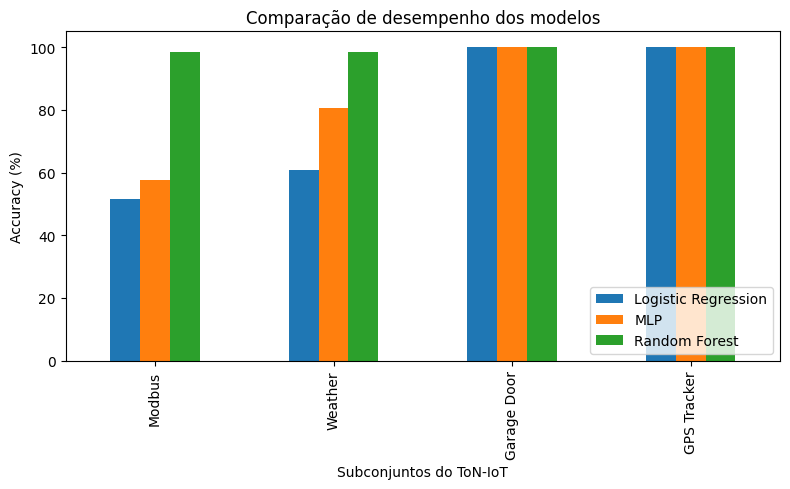

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

dados = {
    "Dataset": ["Modbus", "Weather", "Garage Door", "GPS Tracker"],
    "Logistic Regression": [51.41, 60.93, 100.00, 100.00],
    "MLP": [57.65, 80.41, 100.00, 100.00],
    "Random Forest": [98.46, 98.47, 100.00, 100.00]
}

df_graf = pd.DataFrame(dados)

ax = df_graf.set_index("Dataset").plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Subconjuntos do ToN-IoT")
plt.title("Comparação de desempenho dos modelos")
plt.legend(loc="lower right")
plt.tight_layout()


In [33]:
import os

print(os.getcwd())

C:\Users\Amanda Cristina\Desktop\Mestrado Ufla\Segundo Semestre\PCC557 - Tópicos em IA


In [34]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Amanda Cristina\Desktop\Mestrado Ufla\Segundo Semestre\PCC557 - Tópicos em IA
['.ipynb_checkpoints', '01_ton_iot_federated_learning.ipynb.ipynb', 'Base de dados']


Arquivo salvo!


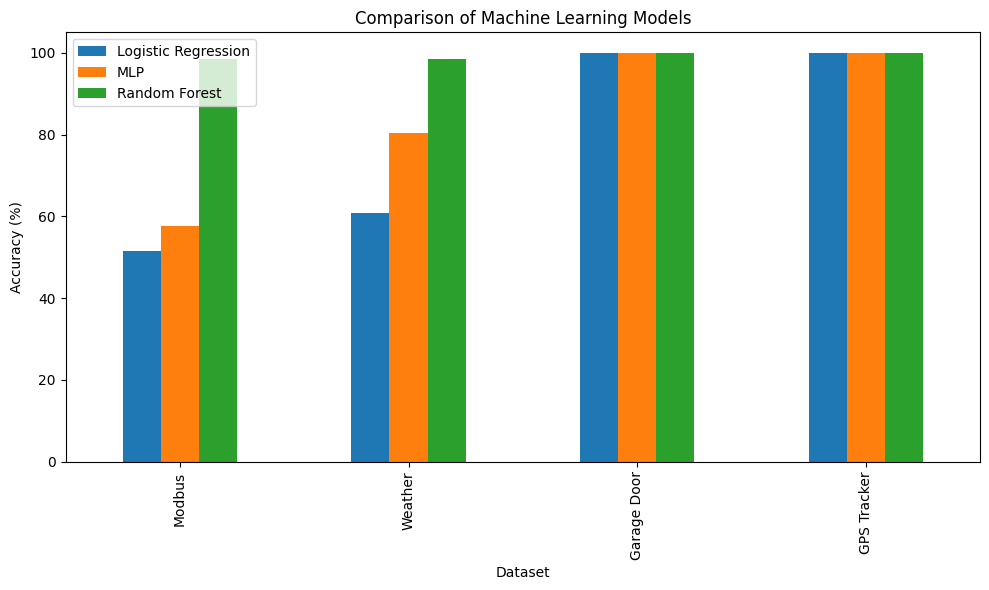

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

dados = {
    "Dataset": ["Modbus", "Weather", "Garage Door", "GPS Tracker"],
    "Logistic Regression": [51.41, 60.93, 100.00, 100.00],
    "MLP": [57.65, 80.41, 100.00, 100.00],
    "Random Forest": [98.46, 98.47, 100.00, 100.00]
}

df = pd.DataFrame(dados)

ax = df.set_index("Dataset").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Dataset")
plt.title("Comparison of Machine Learning Models")
plt.tight_layout()

# SALVA PRIMEIRO
plt.savefig("comparacao_modelos.png", dpi=300)

print("Arquivo salvo!")

# MOSTRA DEPOIS
plt.show()

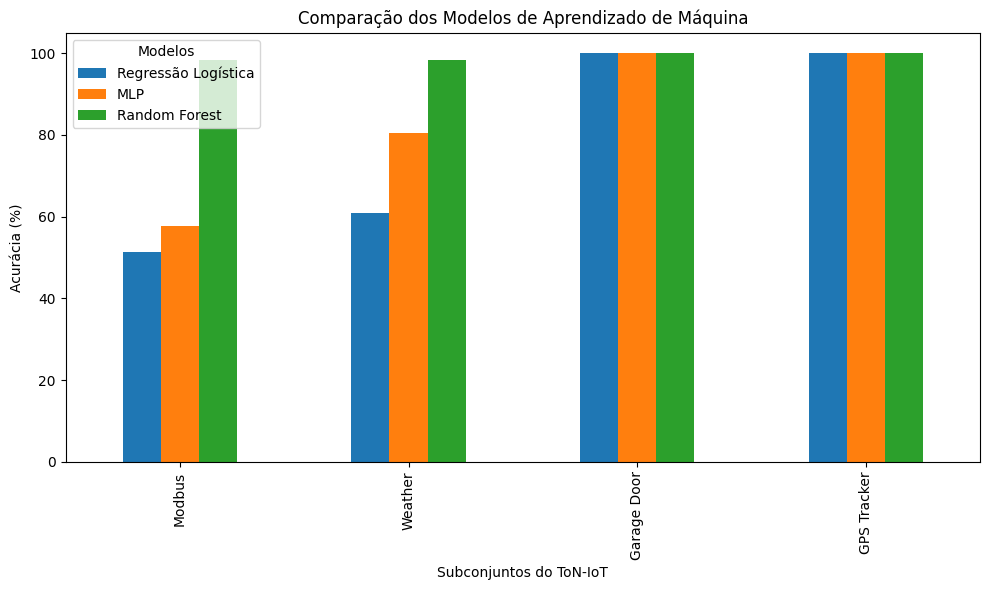

Imagem salva!


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

dados = {
    "Dataset": ["Modbus", "Weather", "Garage Door", "GPS Tracker"],
    "Regressão Logística": [51.41, 60.93, 100.00, 100.00],
    "MLP": [57.65, 80.41, 100.00, 100.00],
    "Random Forest": [98.46, 98.47, 100.00, 100.00]
}

df = pd.DataFrame(dados)

ax = df.set_index("Dataset").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Acurácia (%)")
plt.xlabel("Subconjuntos do ToN-IoT")
plt.title("Comparação dos Modelos de Aprendizado de Máquina")

plt.legend(title="Modelos")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Amanda Cristina\Desktop\comparacao_modelos_pt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Imagem salva!")

In [37]:
import os

print(os.path.exists(r"C:\Users\Amanda Cristina\Desktop\comparacao_modelos_pt.png"))

True


In [38]:
import os

arquivos = os.listdir(r"C:\Users\Amanda Cristina\Desktop")

for arquivo in arquivos:
    if "comparacao" in arquivo.lower():
        print(arquivo)

comparacao_modelos_pt.png


In [1]:
# Carregamento dos dados

# Pré-processamento

# Treinamento da Logistic Regression

# Treinamento da Random Forest

# Treinamento da MLP

# Comparação dos resultados

# Geração do gráfico final